# **Course Work 2**

---

## Notebook objectives
Deploy ML Pipeline for regression or classification task using an
appropriate dataset, data processing Python libraries and Machine Learning
model.

## Inputs
Given Data Set 14 - Image classification with CNN

Data set https://www.kaggle.com/datasets/alessiocorrado99/animals10/data

Pre-processed dataset `../datasets/.npz`

## Outputs

XYZ

## Notes and comments

XZY

## Resources 
https://github.com/Code-Institute-Org/Malaria-walkthrough-ML/blob/main/jupyter_notebooks/01%20-%20DataCollection.ipynb

---

### 1) Import Librarys

In [1]:
%pip install numpy pandas  matplotlib seaborn scikit-learn tensorflow plotly kaggle==1.5.12 kagglehub


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Import packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import itertools
import random
import PIL
import kagglehub
from PIL import Image

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import joblib

#settings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Show error messages only
sns.set_style('whitegrid')

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1777821913.663874   34708 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777821913.665056   34708 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777821913.713744   34708 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:177782191

---

### 2) Load data , importing data set and translating names

Code came from kaggle when you click download

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2


Code came from kaggle under data card the reason why im using it is because "Python dict containing mapping between italian (original) and english names of animals. Since the dataset was initially posted with italian names, and a lot of interesting notebooks use hardcoded names, I preferred to add this file than changing the directory names."

In [4]:
LABEL_MAP = {
    'cane':       'dog',
    'cavallo':    'horse',
    'elefante':   'elephant',
    'farfalla':   'butterfly',
    'gallina':    'chicken',
    'gatto':      'cat',
    'mucca':      'cow',
    'pecora':     'sheep',
    'ragno':      'spider',
    'scoiattolo': 'squirrel'
}

CODE CAME FROM HELP OF AI BECAUSE
Locate the folder that actually contains the Animals-10 class folders.
kagglehub downloads this dataset with an extra nested folder, usually
called "raw-img", so using the download root directly can fail.


In [5]:
DOWNLOAD_PATH = kagglehub.dataset_download('alessiocorrado99/animals10')
def find_animals10_image_dir(download_path, label_map):
    """Return the directory containing the expected Animals-10 class folders."""
    expected = set(label_map.keys())

    # Check the download path itself first, then common nested locations.
    candidate_paths = [download_path, os.path.join(download_path, 'raw-img')]

    # Also search a few levels down in case Kaggle changes the archive layout.
    for root, dirs, _ in os.walk(download_path):
        if root.count(os.sep) - str(download_path).count(os.sep) > 3:
            dirs[:] = []
            continue
        candidate_paths.append(root)

    seen = set()
    for candidate in candidate_paths:
        candidate = os.path.abspath(candidate)
        if candidate in seen or not os.path.isdir(candidate):
            continue
        seen.add(candidate)
        child_dirs = set(d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d)))
        if expected.issubset(child_dirs):
            return candidate

    raise FileNotFoundError(
        "Could not find the Animals-10 image folders. Expected folders like "
        f"{sorted(expected)[:3]} under {download_path!r}. Check the downloaded dataset layout."
    )

DATASET_PATH = find_animals10_image_dir(DOWNLOAD_PATH, LABEL_MAP)

CLASS_NAMES = list(LABEL_MAP.values())
N_LABELS    = len(CLASS_NAMES)
IMG_SIZE    = 64 #Resize all images to 64x64 pixels

print(f"Download path: {DOWNLOAD_PATH}")
print(f"Using image folder: {DATASET_PATH}")
print(f"Number of classes: {N_LABELS}")
print(f"Classes: {CLASS_NAMES}")
print(f"Image target size: {IMG_SIZE}x{IMG_SIZE} px")


Download path: /home/codespace/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2
Using image folder: /home/codespace/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img
Number of classes: 10
Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Image target size: 64x64 px


---

### 3) Data Validation and Preparation

Checking how many images there are and that it imported correctly

In [6]:
# Verify folder structure
folders = [f for f in LABEL_MAP.keys() if os.path.isdir(os.path.join(DATASET_PATH, f))]
missing = [f for f in LABEL_MAP.keys() if f not in folders]

if missing:
    raise FileNotFoundError(f"Missing expected class folders: {missing}")

print(f"Folders found: {folders}")

# Count images per class
image_counts = {}
for folder in folders:
    folder_path = os.path.join(DATASET_PATH, folder)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    english_name = LABEL_MAP.get(folder, folder)
    image_counts[english_name] = len(files)
    print(f"  {english_name:12s} ({folder}): {len(files)} images")

print(f"\nTotal images: {sum(image_counts.values())}")

Folders found: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
  dog          (cane): 4863 images
  horse        (cavallo): 2623 images
  elephant     (elefante): 1446 images
  butterfly    (farfalla): 2112 images
  chicken      (gallina): 3098 images
  cat          (gatto): 1668 images
  cow          (mucca): 1866 images
  sheep        (pecora): 1820 images
  spider       (ragno): 4821 images
  squirrel     (scoiattolo): 1862 images

Total images: 26179


### Validate Images

Check that images can open and following lesson 8.2

In [7]:
def check_images(dataset_path, label_map, sample_size=100):
    """
    Validates a random sample of images from the dataset.
    Checks:
    * File can be opened by PIL
    * Image has 3 colour channels (RGB)
    * Image is not empty / corrupt (no NaN after conversion)
    """
    invalid_count = 0
    valid_count   = 0
    sampled = []

    for folder, english in label_map.items():
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            print(f"WARNING: missing folder for {english}: {folder_path}")
            invalid_count += 1
            continue

        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if not files:
            print(f"WARNING: no image files found for {english}: {folder_path}")
            invalid_count += 1
            continue

        sampled.extend([
            (os.path.join(folder_path, f), english)
            for f in random.sample(files, min(sample_size, len(files)))
        ])

    for img_path, label in sampled:
        try:
            img = Image.open(img_path).convert('RGB')
            arr = np.array(img)
            if arr.ndim != 3 or arr.shape[2] != 3:
                print(f"WARNING ({label}): unexpected channels — {img_path}")
                invalid_count += 1
                continue
            if np.isnan(arr).any():
                print(f"WARNING ({label}): NaN values — {img_path}")
                invalid_count += 1
                continue
            valid_count += 1
        except Exception as e:
            print(f"ERROR ({label}): {img_path} — {e}")
            invalid_count += 1

    print(f"\nValidation complete: {valid_count} valid | {invalid_count} invalid (from {len(sampled)} sampled images)")


print("Checking Images...\n")
check_images(DATASET_PATH, LABEL_MAP, sample_size=50)


Checking Images...


Validation complete: 500 valid | 0 invalid (from 500 sampled images)


### Load and resize images into numpy array

all images are 28x28 pixels and converted into RGB

In [ ]:

def load_images(dataset_path, label_map, img_size, max_per_class=None):

    images = []
    labels = []

    for idx, (folder, english) in enumerate(label_map.items()):
        folder_path = os.path.join(dataset_path, folder)
        if not os.path.isdir(folder_path):
            raise FileNotFoundError(f"Missing folder for '{english}': {folder_path}")

        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if max_per_class is not None:
            files = random.sample(files, min(max_per_class, len(files)))

        loaded = 0
        for fname in files:
            try:
                img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
                img = img.resize((img_size, img_size))
                images.append(np.array(img))
                labels.append(idx)
                loaded += 1
            except Exception as e:
                print(f"Skipped corrupt/unreadable file: {os.path.join(folder_path, fname)} ({e})")

        print(f"  Loaded {loaded} images for '{english}' ({folder})")

    if not images:
        raise ValueError("No images were loaded. Check DATASET_PATH and folder names.")

    X = np.array(images, dtype='uint8')
    y = np.array(labels, dtype='int32')
    return X, y


print("Loading images...\n")
# max_per_class limits images per class to speed up training.
# Increase or set to None to use the full dataset.
X, y = load_images(DATASET_PATH, LABEL_MAP, img_size=IMG_SIZE, max_per_class=500)

print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"Pixel value range: {X.min()} – {X.max()}")


Loading images...

  Loaded 500 images for 'dog' (cane)
  Loaded 500 images for 'horse' (cavallo)
  Loaded 500 images for 'elephant' (elefante)
  Loaded 500 images for 'butterfly' (farfalla)
  Loaded 500 images for 'chicken' (gallina)
  Loaded 500 images for 'cat' (gatto)
  Loaded 500 images for 'cow' (mucca)
  Loaded 500 images for 'sheep' (pecora)
  Loaded 500 images for 'spider' (ragno)
  Loaded 500 images for 'squirrel' (scoiattolo)

X shape: (5000, 64, 64, 3)  |  y shape: (5000,)
Pixel value range: 0 – 255


### Split into train, validation and test sets

Following lessons 8.2 and 9.1 - 80% train and 20 test

In [9]:
# First split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y  # Maintain class balance
)

# Second split validation from train
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train
)

print("* Train set:     ", X_train.shape, y_train.shape)
print("* Validation set:", X_val.shape,   y_val.shape)
print("* Test set:      ", X_test.shape,  y_test.shape)

* Train set:      (3200, 64, 64, 3) (3200,)
* Validation set: (800, 64, 64, 3) (800,)
* Test set:       (1000, 64, 64, 3) (1000,)


Scaling Copied from lesson 9.1

| Before Scaling (uint8) | After Scaling (float32) |
|---|---|
| Pixel values: 0 - 255 | Pixel values: 0.0 - 1.0 |
| Integer type (uint8) | Floating-point (float32)|
| Can cause instability in training | Helps stable and faster training |


In [10]:
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32')   / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f"X_train max after scaling: {X_train.max():.1f}")
print(f"X_train shape: {X_train.shape}  — (samples, height, width, channels)")

X_train max after scaling: 1.0
X_train shape: (3200, 64, 64, 3)  — (samples, height, width, channels)


In [11]:
# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes=N_LABELS)
y_val_cat   = to_categorical(y_val,   num_classes=N_LABELS)
y_test_cat  = to_categorical(y_test,  num_classes=N_LABELS)

print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"Example one-hot vector: {y_train_cat[0]}")

y_train_cat shape: (3200, 10)
Example one-hot vector: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


### Save procesed data

Code from lesson 8.2 and 9.1

In [12]:
os.makedirs('../datasets', exist_ok=True)

np.savez_compressed(
    '../datasets/animals10_processed.npz',
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train_cat,
    y_val=y_val_cat,
    y_test=y_test_cat
)

print("Processed dataset saved to '../datasets/animals10_processed.npz'")

Processed dataset saved to '../datasets/animals10_processed.npz'


---

### 4) EDA

Lable frequency

Code from lesson 9.1

In [13]:
df_freq = pd.DataFrame(columns=['Set', 'Label', 'Frequency']) # AI helped fix this line because i kept getting errors

def count_labels(dataset, dataset_name):
    global df_freq
    unique, counts = np.unique(dataset, return_counts=True)
    for label, frequency in zip(unique, counts):
        df_freq = pd.concat([
            df_freq,
            pd.DataFrame([{'Set': dataset_name, 'Label': CLASS_NAMES[label], 'Frequency': frequency}])
        ], ignore_index=True)
        print(f"* {dataset_name} - {CLASS_NAMES[label]}: {frequency} images")


count_labels(y_train, 'Train')
print()
count_labels(y_val,   'Validation')
print()
count_labels(y_test,  'Test')

* Train - dog: 320 images
* Train - horse: 320 images
* Train - elephant: 320 images
* Train - butterfly: 320 images
* Train - chicken: 320 images
* Train - cat: 320 images
* Train - cow: 320 images
* Train - sheep: 320 images
* Train - spider: 320 images
* Train - squirrel: 320 images

* Validation - dog: 80 images
* Validation - horse: 80 images
* Validation - elephant: 80 images
* Validation - butterfly: 80 images
* Validation - chicken: 80 images
* Validation - cat: 80 images
* Validation - cow: 80 images
* Validation - sheep: 80 images
* Validation - spider: 80 images
* Validation - squirrel: 80 images

* Test - dog: 100 images
* Test - horse: 100 images
* Test - elephant: 100 images
* Test - butterfly: 100 images
* Test - chicken: 100 images
* Test - cat: 100 images
* Test - cow: 100 images
* Test - sheep: 100 images
* Test - spider: 100 images
* Test - squirrel: 100 images


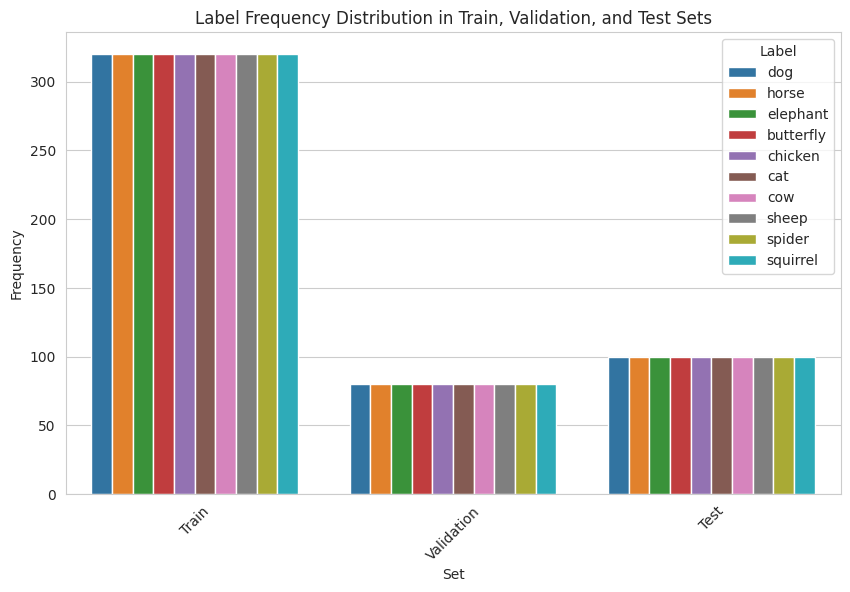

In [14]:
# Visualize the label distribution and save image
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.xticks(rotation=45)
plt.title("Label Frequency Distribution in Train, Validation, and Test Sets")
plt.show()

Sample images

Code from kaggle

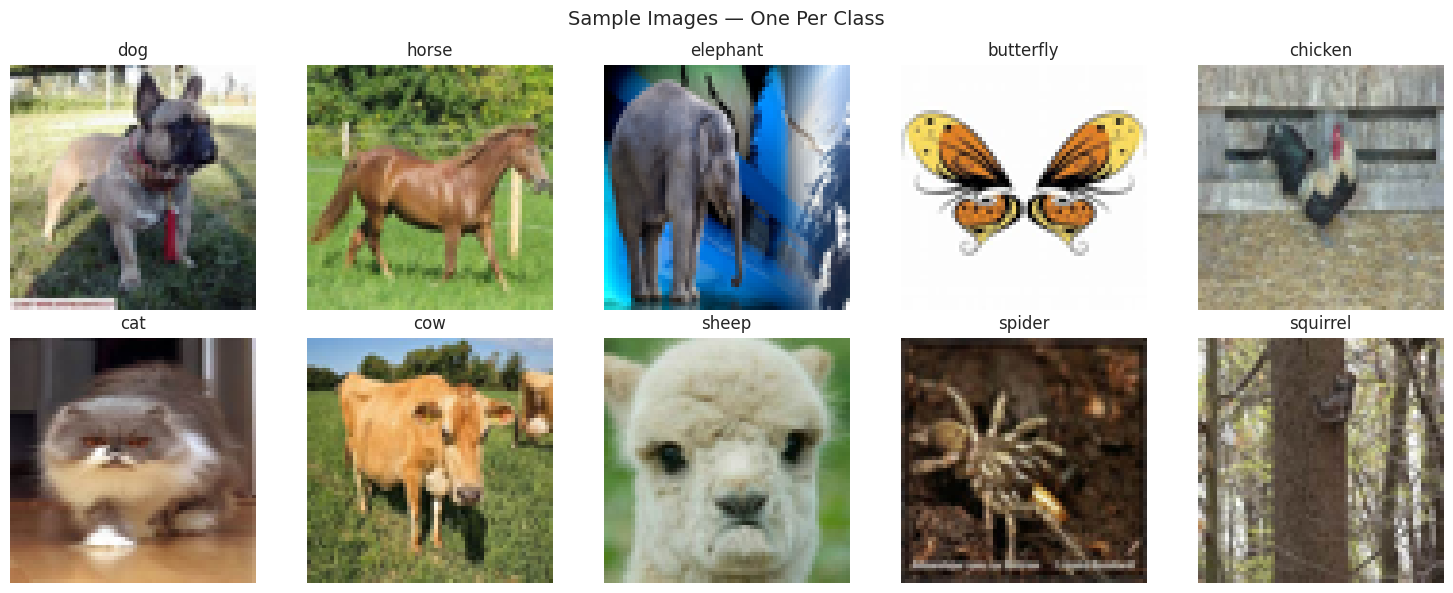

In [17]:
sns.set_style('white')
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for class_idx in range(N_LABELS):
    # Find first occurrence of this class in train set
    match_indices = np.where(y_train == class_idx)[0]
    if len(match_indices) > 0:
        sample_img = X_train[match_indices[0]]
        axes[class_idx].imshow(sample_img)
        axes[class_idx].set_title(CLASS_NAMES[class_idx])
        axes[class_idx].axis('off')

plt.suptitle('Sample Images — One Per Class', fontsize=14)
plt.tight_layout()
plt.show()

pixel intensity

In [18]:
# Mean pixel intensity per channel (R, G, B)
channel_names = ['Red', 'Green', 'Blue']
print("Mean pixel intensity per channel (train set, scaled 0–1):")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: {X_train[:, :, :, i].mean():.4f}  |  std: {X_train[:, :, :, i].std():.4f}")
    

Mean pixel intensity per channel (train set, scaled 0–1):
  Red: 0.5114  |  std: 0.2567
  Green: 0.4930  |  std: 0.2514
  Blue: 0.4049  |  std: 0.2688


---